In [76]:
import bs4
import lxml
import pandas as pd
import urllib
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys


import re
from bs4 import SoupStrainer

from urllib import request
from io import StringIO
import time
from matplotlib import pyplot as plt

import pickle as pckl



### Dons du montant >=50.000 pour les années 2009-actuel

In [2]:
url_base = "https://www.bundestag.de/parlament/praesidium/parteienfinanzierung/fundstellen50000/"
year  = "2024"

In [3]:
url_full = url_base + year
only_table = SoupStrainer('table')
table_request_text = request.urlopen(url_full).read()
table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
raw_table = table.find_all('table', 'table')[0]

In [4]:
df = pd.read_html(str(raw_table))[0]
df

/tmp/ipykernel_8252/1469236618.py:1: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(raw_table))[0]


,Partei,Spende,Spender,Eingang der Spende oder der Spendenan-­ kündigung,"Eingang der Anzeige, Drucksache"
,Juli 2024,Juli 2024,Juli 2024,Juli 2024,Juli 2024
,April 2024,April 2024,April 2024,April 2024,April 2024
0,Dezember 2024,Dezember 2024,Dezember 2024,Dezember 2024,Dezember 2024
1,SPD,35.001 Euro,Verband der Bayerischen Metall und Elektro-Ind...,30.12.2024,30.12.2024
2,FDP,50.000 Euro,Verband der Bayerischen Metall- und Elektro-In...,30.12.2024,30.12.2024
3,FDP,100.000 Euro,Jörg Bantleon Arcisstr. 50 80799 München,27.12.2024,30.12.2024
4,FDP,200.000 Euro,Futrue GmbH Am Haag 14 82166 Gräfelfing,27.12.2024,30.12.2024
...,...,...,...,...,...
141,Bündnis 90/ Die Grünen,50.001 Euro,Verband der Bayerischen Metall- und Elektro-In...,27.12.2023,30.01.2024 Drs. 20/10781
142,FDP,51.000 Euro,Ulrich Horst Marseille Sportallee 1 22335 Hamburg,15.1.2024,16.01.2024 Drs. 20/10781


In [5]:
dfs = []
# get table
year = 2024
for year in range(2009,2026):
    url_full = url_base + str(year)
    only_table = SoupStrainer('table')
    table_request_text = request.urlopen(url_full).read()
    table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
    raw_table = table.find_all('table', 'table')[0]
    df = pd.read_html(StringIO(str(raw_table)))[0]

    # clean up
    df_dons = df.iloc[:,: 5].set_axis(['Partie', 'Montant', 'Donneur', 'Date', 'Date Publication'], axis=1)
    df_dons = df_dons[df_dons['Montant'].str.match('\d+\.\d\d\d')]
    df_dons = df_dons[df_dons['Date'].str.match('\d{1,2}.\d\d.\d\d\d\d$', flags=re.U)]
    df_dons['Montant'] = df_dons['Montant'].apply(lambda x: re.search(r'\d{1,3}(\.\d{3})*', x).group(0))
    df_dons['Montant'] = df_dons['Montant'].apply(lambda x: int(x.replace('.','')))
    df_dons['Date'] = pd.to_datetime(df_dons['Date'],format= '%d.%m.%Y')
    df_dons
    dfs.append(df_dons)

df_don_complet = pd.concat(dfs)
df_don_complet

,Partie,Montant,Donneur,Date,Date Publication
1,CDU,100000,Südwestmetall Verband der Metall- und Elektroi...,2009-12-28,29.12.2009
5,CDU,150000,Frau Johanna Quandt Seedammweg 55 61352 Bad Ho...,2009-10-01,02.10.2009
6,CDU,150000,Herr Stefan Quandt Seedammweg 55 61352 Bad Hom...,2009-10-01,02.10.2009
7,CDU,150000,Frau Susanne Klatten Seedammweg 55 61352 Bad H...,2009-10-01,02.10.2009
8,FDP1,300000,Substantia AG Berliner Allee 21 40212 Düsseldorf,2009-10-13,19.10.2009
...,...,...,...,...,...
79,FDP,50000,Johannes Peter Huth 61 Rutland Gate London SW7...,2025-01-02,03.01.2025
80,CDU,50000,Johannes Peter Huth 61 Rutland Gate London SW7...,2025-01-02,03.01.2025
81,Bündnis 90/ Die Grünen,35001,vbm- Verband der Bayerischen Metall- und Elekt...,2024-12-30,02.01.2025
82,CDU,167000,Torsten Toeller c/o Allegro Invest SE Westpreu...,2024-12-27,02.01.2025


## Financement des parties

In [6]:
import tabula

In [9]:
parties = [
    'CDU',
    'SPD',
    'GRÜNE',
    'AfD',
    'FDP',
    'CSU',
    'DIE LINKE'
]

In [18]:
from PyPDF2 import PdfReader

rapport_path = "rechenschaftsberichte/2022.pdf"
reader = PdfReader(rapport_path)
number_of_pages = len(reader.pages)


# récuperer la page correspondante à chaque partie
page = reader.pages[0]
text = page.extract_text()
parties_trouves = []
pages_correspondants = []
for partie in parties:
    page_trouve = re.findall(f'(?<={partie})\s+\d+', text)
    if len(page_trouve) > 0:
        print(page_trouve)
        page_trouve = int(page_trouve[0])
        print(partie, " ", page_trouve)
        parties_trouves.append(partie)
        pages_correspondants.append(page_trouve)
print(parties_trouves)
print(pages_correspondants)

# récuperer le rapport financier de chaque partie
dfs_rapports = tabula.read_pdf(rapport_path,pages=pages_correspondants)
print(len(dfs_rapports))

for dfs in dfs_rapports:
    print(dfs)

len(dfs_rapports)
dfs_rapports

[' 3']
CDU   3
[' 85']
SPD   85
['  163']
GRÜNE   163
[' 237']
AfD   237
[' 279']
FDP   279
['  309']
CSU   309
['  333']
DIE LINKE   333
['CDU', 'SPD', 'GRÜNE', 'AfD', 'FDP', 'CSU', 'DIE LINKE']
[3, 85, 163, 237, 279, 309, 333]
7
                              Einnahmen- und      Unnamed: 0  2022 Unnamed: 1  \
0                                        NaN             EUR   NaN          %   
1                 Einnahmen der Gesamtpartei             NaN   NaN        NaN   
2                       1. Mitgliedsbeiträge   36.405.599,34   NaN      26,70   
3      2. Mandatsträgerbeiträge und ähnliche             NaN   NaN        NaN   
4                       regelmäßige Beiträge   22.323.445,17   NaN      16,37   
5        3. Spenden von natürlichen Personen   14.008.708,90   NaN      10,27   
6       4. Spenden von juristischen Personen    7.339.887,57   NaN       5,38   
7     5. Einnahmen aus Unternehmenstätigkeit             NaN  0,00       0,00   
8            5a. Einnahmen aus Beteiligu

[                              Einnahmen- und      Unnamed: 0  2022 Unnamed: 1  \
 0                                        NaN             EUR   NaN          %   
 1                 Einnahmen der Gesamtpartei             NaN   NaN        NaN   
 2                       1. Mitgliedsbeiträge   36.405.599,34   NaN      26,70   
 3      2. Mandatsträgerbeiträge und ähnliche             NaN   NaN        NaN   
 4                       regelmäßige Beiträge   22.323.445,17   NaN      16,37   
 5        3. Spenden von natürlichen Personen   14.008.708,90   NaN      10,27   
 6       4. Spenden von juristischen Personen    7.339.887,57   NaN       5,38   
 7     5. Einnahmen aus Unternehmenstätigkeit             NaN  0,00       0,00   
 8            5a. Einnahmen aus Beteiligungen             NaN  0,00       0,00   
 9        6. Einnahmen aus sonstigem Vermögen    1.952.077,46   NaN       1,43   
 10         7. Einnahmen aus Veranstaltungen,             NaN   NaN        NaN   
 11           Ve

In [19]:
partie = 'CDU'
annee = '2024'
data = {'partie': [], 'depense': [], 'amont': [], 'annee': []}


for i in range(len(dfs_rapports)):
    df_rapport_financement = pd.DataFrame(columns=['Partie','Depense','Amont','Annee'])
    dfs_test = dfs_rapports[i].copy().iloc[:, 0:2].dropna()
    #print(dfs_test)
    regex = r'-?\d{1,3}(\.\d{3})*'
    dfs_test = dfs_test.set_axis(['Depense','Amont'],axis=1)
    dfs_test = dfs_test[dfs_test['Amont'].str.match(regex)]
    dfs_test['Amont'] = dfs_test['Amont'].apply(lambda x: x.replace(' ',''))

    dfs_test['Amont']= dfs_test['Amont'].apply(lambda x: x[:-3])
    dfs_test['Amont']= dfs_test['Amont'].apply(lambda x: re.search(regex, x).group(0))
    dfs_test['Amont'] = dfs_test['Amont'].apply(lambda x: int(x.replace('.','')))

    # Trouver les dons
    #print(dfs)
   # print(dfs_test)
    print(dfs_test[dfs_test['Depense'].str.contains('Spenden')])

    

                                Depense     Amont
5   3. Spenden von natürlichen Personen  14008708
6  4. Spenden von juristischen Personen   7339887
                                Depense    Amont
5   3. Spenden von natürlichen Personen  7429801
6  4. Spenden von juristischen Personen  1805152
                                Depense    Amont
5   3. Spenden von natürlichen Personen  4837530
6  4. Spenden von juristischen Personen   697190
                                Depense    Amont
5   3. Spenden von natürlichen Personen  3866320
6  4. Spenden von juristischen Personen   104240
                                 Depense    Amont
4   3. Spenden l()n natürlichen Personen  3793539
5  4. Spenden l()n juristischen Personen  1678265
                                Depense    Amont
5   3. Spenden von natürlichen Personen  3171066
6  4. Spenden von juristischen Personen  1517641
                                Depense    Amont
5   3. Spenden von natürlichen Personen  2108832
6  4. Spenden 

# Résultats des élection fédérales allemandes

In [35]:
url = 'https://www.bundestag.de/parlament/wahlen/ergebnisse_seit1949-244692'
only_table = SoupStrainer('table')
table_request_text = request.urlopen(url).read()
table = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_table)
raw_table = table.find_all('table', 'table')[0]
df = pd.read_html(str(raw_table))[0]

/tmp/ipykernel_8252/2794489338.py:6: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df = pd.read_html(str(raw_table))[0]


In [46]:
df_formatted = df.copy()
df_formatted.iloc[:,1:] = df_formatted.iloc[:,1:].apply(lambda x:x/10)

/tmp/ipykernel_8252/4025240561.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     24.1
1     32.9
2     41.5
3     33.8
4     35.2
5     38.5
6     35.2
7     41.5
8     43.8
9     44.3
10    48.8
11    44.5
12    48.6
13    44.9
14    46.1
15    47.6
16    45.3
17    50.2
18    45.2
19    31.0
Name: CDU/CSU, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_formatted.iloc[:,1:] = df_formatted.iloc[:,1:].apply(lambda x:x/10)
/tmp/ipykernel_8252/4025240561.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     25.7
1     20.5
2     25.7
3     23.0
4     34.2
5     38.5
6     40.9
7     36.4
8     33.5
9     37.0
10    38.2
11    42.9
12    42.6
13    45.8
14    42.7
15    39.3
16    36.2
17    31.8
18    28.8
19    29.2
Name: SPD, dtype: float64' has dtype incompatible with int6

In [47]:
df_formatted

,Jahr,CDU/CSU,SPD,FDP,Die Grünen,Bündnis 90/Die Grünen,Die Linke. PDS,AfD,Sonstige
0,2021,24.1,25.7,11.5,NaN,14.8,4.9,10.3,8.7
1,2017,32.9,20.5,10.7,NaN,8.9,9.2,12.6,5.0
2,2013,41.5,25.7,4.8,NaN,8.4,8.6,4.7,6.3
3,2009,33.8,23.0,14.6,NaN,10.7,11.9,NaN,6.0
4,2005,35.2,34.2,9.8,NaN,8.1,8.7,NaN,4.0
5,2002,38.5,38.5,7.4,NaN,8.6,4.0,NaN,3.0
6,1998,35.2,40.9,6.2,NaN,6.7,5.1,NaN,5.9
7,1994,41.5,36.4,6.9,NaN,7.3,4.4,NaN,3.5
8,1990,43.8,33.5,11.0,3.8,1.2,2.4,NaN,4.3
9,1987,44.3,37.0,9.1,8.3,NaN,NaN,NaN,1.3


# Scraping sujets articles

In [3]:
only_filter_count = SoupStrainer(class_="filter-count")
def get_faz_mentions(subject, start_year=1993,end_year = 2025,sleep=0):
    mentions = []
    years = []
    for year in range(start_year,end_year):
        url = f"https://fazarchiv.faz.net/faz-portal/faz-archiv?q={subject}&source=&max=10&sort=&offset=0&&_ts={int(time.time())}&DT_from=01.01.{year}&DT_to=01.01.{year+1}&timeFilterType=0#hitlist"
        table_request_text = request.urlopen(url).read()
        site = bs4.BeautifulSoup(table_request_text, "html.parser",parse_only=only_filter_count)
        site = str(site)
        site = site.replace('.','')
        filter_results = re.findall(pattern=r'(?<=\()\d+(?=\))',string=str(site))
        if len(filter_results) > 0:
            number_of_mentions = max([int(x) for x in filter_results])
        else:
            number_of_mentions = 0
        mentions.append(number_of_mentions)
        years.append(year)
        time.sleep(sleep)
    return pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')

In [2]:
def get_lemonde_mentions(subject, start_year=2010,end_year = 2024,sleep=0):

    only_page_count_le_monde = SoupStrainer(class_="river__pagination river__pagination--page-search ")
    only_article_section_le_monde = SoupStrainer(class_="teaser teaser--inline-picture  ")

    mentions = []
    years = []

    options = webdriver.ChromeOptions()
    driver = webdriver.Chrome(options=options)

    # Provoquer demande d'acceptation de cookies
    test_url = f"https://lemonde.fr/recherche/?search_keywords={'test'}&start_at=1%2F1%2F{2000}&end_at=1%2F1%2F{2001}&search_sort=relevance_desc"
    driver.get(test_url)
    driver.add_cookie({"name": "euconsent-v2", "value": "CQMgjEAQMgjEAFzABBFRBbFsAP_gAAAAAAqII7MB7C7OQSFicX51AOsESY1ewkBSoEAgBAABgQgBABgQsIwRkGAKIADAAqAKAAIAImRBIQAtGAjABAAAQIAAASCEAECAABAAJKAAAEAQAAEACAgACQEAAAAAgEAAAAQAgAIAAEooQERAAgAgLAAAIAABAIAEAgAIAAAAAAAAAAAAAGAAAAAAAAAAAAAAAAAAEEBAARBQiIACwICQggDCCBACoIQAIAAAQAAAAwAAAAAwIUAYACDABAAAAAAAEAAAAARAAgAAAgAQgAAAAIEAAAAAAAAAAAAgAABAAAAAAAAAAAAQAAIAAAAAAAAAAAAIAQAAAAAAAICAAAAAQFgAAAAAAgEAAAAAAAAAAAAAAAAAAACAMEgAwABBAQdABgACCAhCADAAEEBCUAGAAIICFIAMAAQQELQAYAAggIA", "sameSite": "Lax"})
    driver.add_cookie({"name": "lmd_consent", "value": "%7B%22userId%22%3A%22e5912aad-e232-4533-9da0-cdd43a427087%22%2C%22timestamp%22%3A%221739010630.749987654%22%2C%22version%22%3A1%2C%22cmpId%22%3A371%2C%22displayMode%22%3A%22cookiewall%22%2C%22purposes%22%3A%7B%22analytics%22%3Atrue%2C%22ads%22%3Atrue%2C%22personalization%22%3Atrue%2C%22mediaPlatforms%22%3Atrue%2C%22social%22%3Atrue%7D%7D", "sameSite": "Lax"})
    time.sleep(3)

    # commencer scrapping
    for year in range(start_year,end_year):
        url = f"https://lemonde.fr/recherche/?search_keywords={subject}&start_at=1%2F1%2F{year}&end_at=1%2F1%2F{year+1}&search_sort=relevance_desc"

        driver.get(url)
        time.sleep(sleep)
        
        # Get the page source after JavaScript has rendered the content
        page_source = driver.page_source
        site = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_page_count_le_monde)
        site = str(site)
        filter_results = re.findall(pattern=r'(?<=page\=)\d+(?=\")',string=str(site))
        if len(filter_results) > 0:
            number_of_pages = max([int(x) for x in filter_results])
        else:
            number_of_pages = 0


        # number of sections
        article_sections = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_article_section_le_monde)
        number_of_articles = len(re.findall(r'\<section class\=',str(article_sections)))
        mentions.append(number_of_pages * number_of_articles)
        years.append(year)
    driver.close()
    return pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')



In [4]:
df = get_lemonde_mentions('merkel',2007,2025,sleep=3)

In [5]:
df

,Mentions
Year,
2007,760
2008,640
2009,800
2010,880
2011,1240
2012,1240
2013,1040
2014,760
2015,960


<Axes: xlabel='Year'>

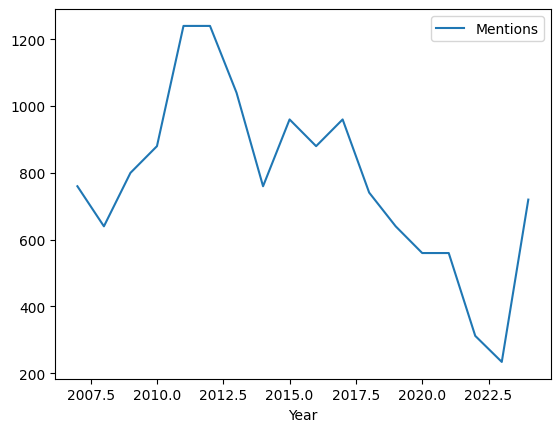

In [6]:
df.plot()


Text(0.5, 1.0, 'Total mentions of given topic in German Newspaper FAZ')

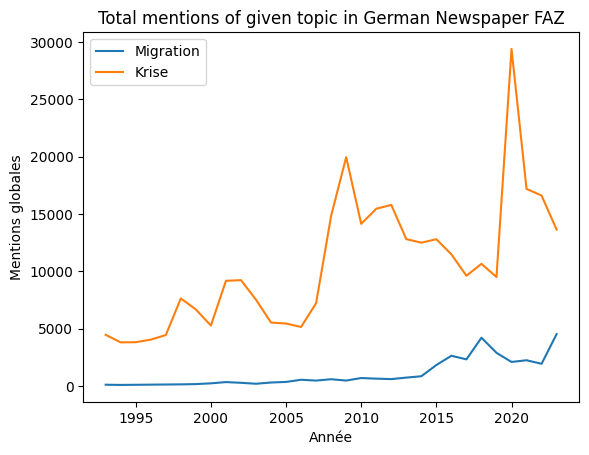

In [77]:
plt.plot(range(1993,2024),mentions_migration,label="Migration")
plt.plot(range(1993,2024),mentions_crise,label="Krise")

plt.xlabel('Année')
plt.ylabel('Mentions globales')
plt.legend()
plt.title('Total mentions of given topic in German Newspaper FAZ')

In [36]:
""" url = 'https://www.liberation.fr/recherche/?query=refugies'
# Libération
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(10)
cookies = driver.get_cookies()
with open('scrapping/liberation_cookies.pckl','wb') as f:
    pckl.dump(cookies,f) """

In [109]:
url = 'https://www.liberation.fr/recherche/?query=refugies'

mentions = []
years = []

# Libération
options = webdriver.ChromeOptions()
driver = webdriver.Chrome(options=options)
driver.get(url)
time.sleep(3)
driver.switch_to.frame(driver.find_element(By.ID,"sp_message_iframe_1223720"))
cookie_notice = driver.find_element(By.ID, 'notice')
cookie_notice.find_element(By.XPATH,'//*[@title="Accepter et continuer"]').click()

#print(driver.find_element(By.CLASS_NAME, 'message-component message-button no-children focusable start-focus sp_choice_type_11'))
driver.switch_to.default_content()
tries = 0
time.sleep(3)
for year in range(2010,2024):
    #print(driver.find_elements(By.ID, "datepicker_from"))
    while (driver.find_elements(By.ID, "datepicker_from") == []):
        if tries >= 3:  
            raise Exception(ConnectionError)
        driver.refresh()
        time.sleep(3)
        tries += 1
    start_year = year
    end_date = start_year + 1
    datepicker_from = driver.find_element(By.ID,"datepicker_from")
    datepicker_from.clear()

    datepicker_from.send_keys(f"01/01/{start_year}")
    datepicker_from.send_keys(Keys.TAB)
    driver.find_element(By.ID,"datepicker_to").send_keys(f"01/01/{end_date}")
    driver.execute_script('searchPage.applyDateRange();')
    time.sleep(1)

    only_filter_liberation = SoupStrainer(id="resultdata")
    page_source = driver.page_source
    site = bs4.BeautifulSoup(page_source, 'html.parser',parse_only=only_filter_liberation)
    pattern = r'(?<=Affichage de )\d+(?= résultats)'

    filter_results = re.findall(pattern,str(site))
    if len(filter_results) > 0:
        number_of_mentions = filter_results[0]
    else:
        number_of_mentions = 0
    years.append(year)
    mentions.append(int(number_of_mentions))
    print(mentions[-1])
driver.close()
df = pd.DataFrame({'Year':years, 'Mentions': mentions}).set_index('Year')
df


301
471
431
472
653
1204
1262
908
843
585
532
627
922
953


,Mentions
Year,
2010,301
2011,471
2012,431
2013,472
2014,653
2015,1204
2016,1262
2017,908
2018,843


<Axes: xlabel='Year'>

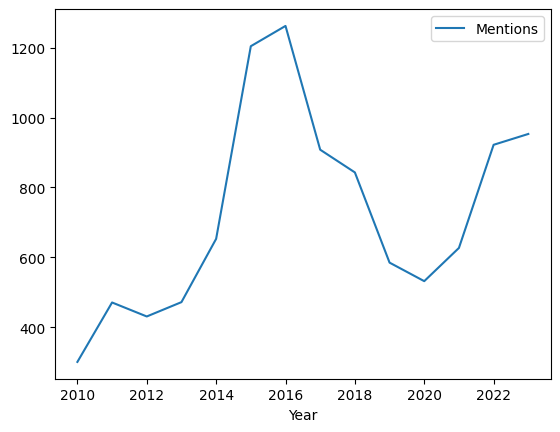

In [110]:
df.plot()